# Moment-of-symmetry scales — the short tour

Look at the white keys of a piano, C up to C. Seven notes. Measure the gaps between
them and there are only two sizes: five whole tones and two semitones.

That is worth pausing on. Of the 792 ways to choose seven notes out of twelve, only 48
come out with two gap sizes. The other 744 have three.

The tidiness comes from how the scale is built. Start on F and go up by fifths: F, C,
G, D, A, E, B. Fold each note back into a single octave and sort them, and the white
keys are what you get — with exactly two gap sizes.

Scales built this way are called **well formed**, or **moments of symmetry**. The
interval you keep stacking is the **generator**; the interval you fold back into is the
**period**. Stop the same stack of fifths at five notes and the pentatonic falls out;
carry on to twelve and you have the chromatic scale.

Three familiar scales, one generator, three places to stop. And the fifth is one angle
out of every angle there is: around it lies a large microtonal hinterland an ordinary
keyboard cannot reach.

`biotuner.mos` implements the combinatorics of

> Milne, A.J., Carlé, M., Sethares, W.A., Noll, T., Holland, S. (2011).
> *Scratching the Scale Labyrinth.* In Mathematics and Computation in Music,
> LNAI 6726, 180–195.

and adds the question the paper does not ask: **given a biosignal's spectral peaks,
which well-formed scale best explains them?**

This notebook is the argument, not the manual. It shows the map, one scale on it, the
three ways to travel across it, both directions of the biosignal fit, and how to read a
fit without fooling yourself. The exhaustive tour is in
[mos.ipynb](mos.ipynb); the interactive widgets are in [explorers.ipynb](explorers.ipynb).

In [1]:
# Render figures inline whatever backend the environment picked. A docs
# build with MPLBACKEND=Agg makes plt.show() a no-op, which drops every
# figure out of this notebook and leaves the prose describing nothing.
%matplotlib inline

import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio
from matplotlib.lines import Line2D

import biotuner.mos as M

FIFTH = 3 / 2
plt.rcParams["figure.dpi"] = 96
pd.set_option("display.width", 150)

C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\epic-morse-ded0d5\biotuner\biotuner_object.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


## 1. The idea in one picture

Every well-formed scale up to eighteen notes, drawn at once. This picture is the
*labyrinth* of the paper's title, and the rest of the notebook keeps coming back to it.
It repays a slow read, so here it is one coordinate at a time.

**Angle is the generator.** The rim is labelled in cents and one full turn is one
period, so a 702-cent fifth against a 1200-cent octave sits 0.585 of the way round. That
is the bold ray running down and to the left.

**Radius is the note count.** Ring *N* carries every *N*-note moment of symmetry. Small
scales live near the middle, crowded ones out at the edge. Colour says the same thing
again, dark at the centre and bright at the rim; nothing is encoded in it that the
radius does not already say.

An angle and a ring are enough to name a scale. What the picture adds is that not
every pairing exists, and the crowded outer rings are the fussy ones: ring 18 takes
fewer than one angle in five.

One thing to settle before the arcs make sense. The opening stacked one exact fifth,
but nothing forces the generator to be exact. Flatten it a few cents and the seven
notes all shift a little, and five wide gaps and two narrow ones is still what you
have. A scale is not one angle. It is a stretch of them.

**Each arc is such a stretch.** Slide the generator off either end and the scale stops
being itself, because at one end the small step has shrunk away to nothing and at the
other it has grown until it equals the large one. The thicker segment inside the arc is
where the scale is also **coherent**: large step under twice the small one.

The short tick partway along each arc is the tuning at which the two step sizes are
exactly equal, and it splits the arc in two. One side of the tick is a scale; the other
side is the same notes with wide and narrow swapped. So an arc holds a *pair*, not one
scale — which is why the summary in section 2 prints a valid range covering only the
stretch on its own side of the tick, and names the scale on the far side its `inverse`.

**The spokes are the equal temperaments.** *N*-EDO is the period cut into *N* equal
parts. Each spoke runs in from the rim and touches the ring of its own note count
without crossing it. An equal division has a single step size, so it is not itself a
moment of symmetry: what a spoke lands on is one of those ticks, the tuning at which
a scale on that ring has flattened out.

Now follow the fifth. Its ray is not a spoke, because a pure fifth is not an equal
division of anything. Going outwards it picks up a marker on rings 3, 5, 7, 12 and 17,
the pentatonic and the diatonic among them. Those are the only note counts at which a
stack of fifths has two step sizes rather than three or more, and section 3 says why.

Every other angle in the picture is a generator no keyboard offers, with its own list of
note counts.

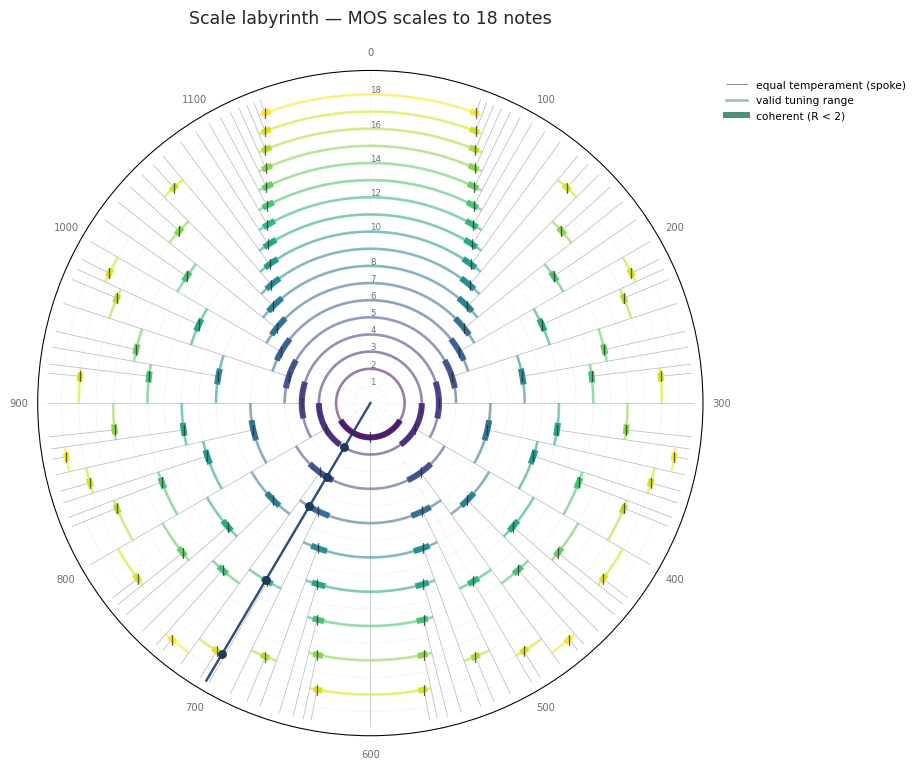

In [2]:
fig, ax = M.plot_labyrinth(18, highlight=M.generator_fraction(FIFTH))
plt.show()

## 2. One scale, up close

Take the diatonic off the map and look at it on its own.

Putting it on the map took two decisions, and `MOSScale` keeps them apart.

**How many of each step.** Five large, two small — `5L2s`. That pair of counts is the
scale's **signature**, and it is what the ring in section 1 was counting.

**How wide those steps actually are.** That is what `tuning=31` sets. Cut the octave into
31 equal parts and make every step a whole number of them: five parts for a large step,
three for a small. Five large and two small then account for the octave exactly,
5×5 + 2×3 = 31.

One part is 1200/31 = 38.7 cents. That is where the summary gets its 193.5-cent large
step, five parts, and its 696.774-cent generator, eighteen.

Same signature, different tuning, same scale. That freedom is what the arcs in section 1
were drawing.

This particular choice has a name. Stack four of these 696.774-cent fifths, drop two
octaves, and you land on 387.1 cents — within a cent of the pure 5/4 major third at
386.3. A fifth flattened until that happens is **meantone**, and 387.1 is sitting in
the printed degrees below.

Now read the summary from the top.

The **word** `LLLsLLs` is the order the two sizes come in, and it is not an arbitrary
order: large and small are spread as evenly as two sizes can be. That is what makes it
the Christoffel word for `5L2s`. Each signature has exactly one.

The **hardness** `R = L/s` is 1.667 here, so a large step is two-thirds again as wide as
a small one. R is the single number that says how a signature has been tuned, and two of
its values are landmarks: at `R = 1` the two sizes have met and the scale has flattened
into an equal division, and at `R = 2` the small step is exactly half the large one.

Between those two the scale is **proper**. Number the intervals by how many scale steps
they span; proper means the numbering never lies about the widths, so every three-step
interval is wider than every two-step one, every four-step wider than every three-step,
all the way up. A listener can hear how many steps an interval covers without knowing
which notes made it.

Propriety belongs to the tuning, not to the signature. Tune the same `LLLsLLs` in
Pythagorean, fifths at 702 cents rather than 696.8, and it breaks: the tritone F–B spans
three steps and measures 611.7 cents, while B–F spans four and measures 588.3. A
four-step interval narrower than a three-step one is exactly what proper forbids.

Two cautions the printed summary will otherwise trip you on. First, `coherent` and
`proper` are one property under two names here — the coherent range *is* the range over
which the scale is proper, which is why the summary prints them on one line. Second,
Pythagorean is still inside the printed `valid range` of 685.7 to 720 cents. It is a
perfectly legal `5L2s`; it has just left the coherent part of that range.

Under the summary are the degrees, the steps accumulated: seven pitch classes in cents
above the tonic.

And the last line before them: `embedded in 12 notes`. Seven notes, and the smallest
well-formed scale that can contain them has twelve. Not eleven, not thirteen. The next
section is about where that number comes from.


In [3]:
diatonic = M.MOSScale.from_signature(5, 2, tuning=31)
print(diatonic.summary())
print()
print("degrees (cents):", [round(c, 1) for c in diatonic.cents])

5L2s  (7 notes)   LLLsLLs
  generator       696.774 c  (ratio 1.495518, g = 0.580645)
  period         1200.000 c  (ratio 2.000000)
  steps          L = 193.548 c,  s = 116.129 c,  R = 1.6667
  valid range    4/7 .. 3/5   (685.7 .. 720.0 c)
  coherent over  4/7 .. 7/12   -> proper
  landmarks      equalized 4/7 = 7-EDO,  s->0 at 3/5 = 5-EDO,  L->0 at 1/2 = 2-EDO
  inverse        2L5s
  embedded in    12 notes (equal at 7/12)

degrees (cents): [0.0, 193.5, 387.1, 580.6, 696.8, 890.3, 1083.9]


## 3. The map is a tree

Why twelve? The chromatic scale has twelve notes and the diatonic sits inside it, and
that is usually offered as a fact about Western music. It is a fact about arithmetic.

The labyrinth is a Stern–Brocot tree bent into a circle, and the note counts are where
that tree puts them. The tree is built by one operation, the **mediant**: add the two
numerators, add the two denominators. The mediant of 4/7 and 3/5 is 7/12.

The same addition on step counts gives every signature exactly two children,
`(nL, nL+ns)` and `(nL+ns, ns)`. For `5L2s` that is `5L7s` and `7L2s` — and both have
twelve notes.

There is no eleven-note or thirteen-note scale for the diatonic to embed in, because the
addition does not produce one.

The plot below is that tree, unbent. Each node is a fraction `p/q`, meaning a generator
of `p` steps out of `q` equal ones — the tuning at which that scale's two step sizes
become the same size. The grey pair under each node is the signature the node bounds
together with that signature's inverse, so `4/7` reads `2L5s | 5L2s`, and `5L2s` is the
diatonic.

Taking mediants of fractions and taking mediants of step counts are the same move seen
twice.

The red line traces the fifth's own way down the tree: 1/2, 2/3, 3/5, 4/7, 7/12. Read
off the denominators — 2, 3, 5, 7, 12 — and from 3 onwards they are the rings the
fifth had markers on in section 1; the two-note scale is trivial and gets none. That
is what section 1 promised this one would explain.

The printed list carries the same descent further, to 17, 29, 41 and 53, and stops
there only because 53 is where we asked it to stop. **Cardinality** is just the note
count, and `sb_path` reports the descent as the sequence of left and right branches
taken to reach it.

The practical payoff: tracing a generator down the tree enumerates its whole scale
family exactly, with no search.

children of 5L2s    [(5, 7), (7, 2)]   parent (3, 2)
5L2s embeds in      12 notes (equalized at 7/12)
path down the tree  RLLRRLLL
MOS cardinalities   [2, 3, 5, 7, 12, 17, 29, 41, 53]


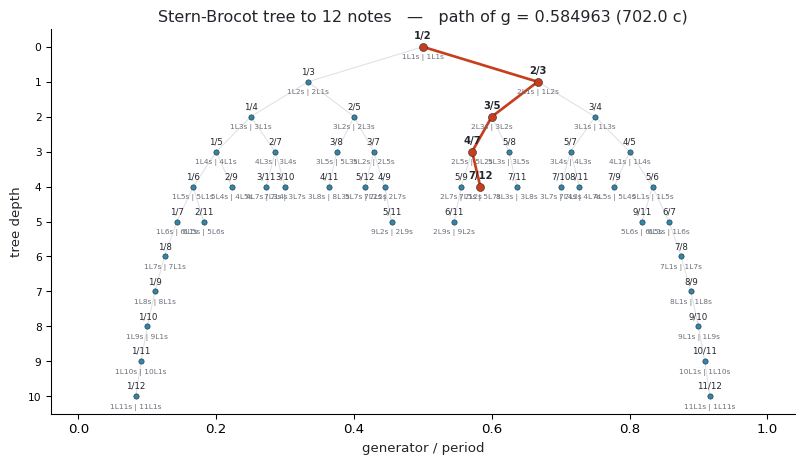

In [4]:
g = M.generator_fraction(FIFTH)
notes, equalized = M.embedding(5, 2)
print("children of 5L2s   ", M.signature_children(5, 2),
      "  parent", M.signature_parent(5, 2))
print(f"5L2s embeds in      {notes} notes (equalized at {equalized})")
print("path down the tree ", M.sb_path(g, 53))
print("MOS cardinalities  ", M.mos_cardinalities(g, 53, include_trivial=True))

fig, ax = M.plot_stern_brocot(12, highlight_generator=g, figsize=(10.0, 5.2))
plt.show()

## 4. Travelling between scales

The labyrinth has been a map of places so far. Milne et al. describe it as a surface a
musician moves *across*, choosing structure and tuning together, and
`biotuner.mos.morph` makes the movement itself the object.

Say you are on the familiar diatonic in 12-EDO and want to arrive at `4L3s` in 19-EDO.
What changes along the way? There are three answers, and they are genuinely different
journeys rather than three spellings of one.

| strategy | what moves | shape of the path | every frame well formed? |
| --- | --- | --- | --- |
| `tuning_morph` | the generator; the note count is held | along one ring | yes |
| `tree_morph` | the structure, one legal move at a time | hops between rings | yes |
| `voice_morph` | the notes themselves | leaves the map | no, deliberately |

The last column is where they part company: two routes stay on the map the whole way,
and the third steps off it on purpose.

Same two endpoints, three routes. The top row of the figure sketches each path on the
labyrinth of section 1 — shape only, the numbers are in the table below.

Find the two markers first: a circle where the journey starts, a square where it
ends, both outlined in red. The dots along the path are coloured by time, dark at
the start and bright at the arrival, which is why the square looks yellow.

The pale red fan behind the path is not the path. It is every note count the current
generator is well formed at, drawn so the journey reads as a wedge rather than a
speck; watch it branch as the generator slides.

The tuning morph's own route stays on the seven-note ring the whole way, which is what
the table means by *along one ring*.

The bottom row is the same journey as voice leading, one line per tone, with the
landmarks each route crosses marked in red.

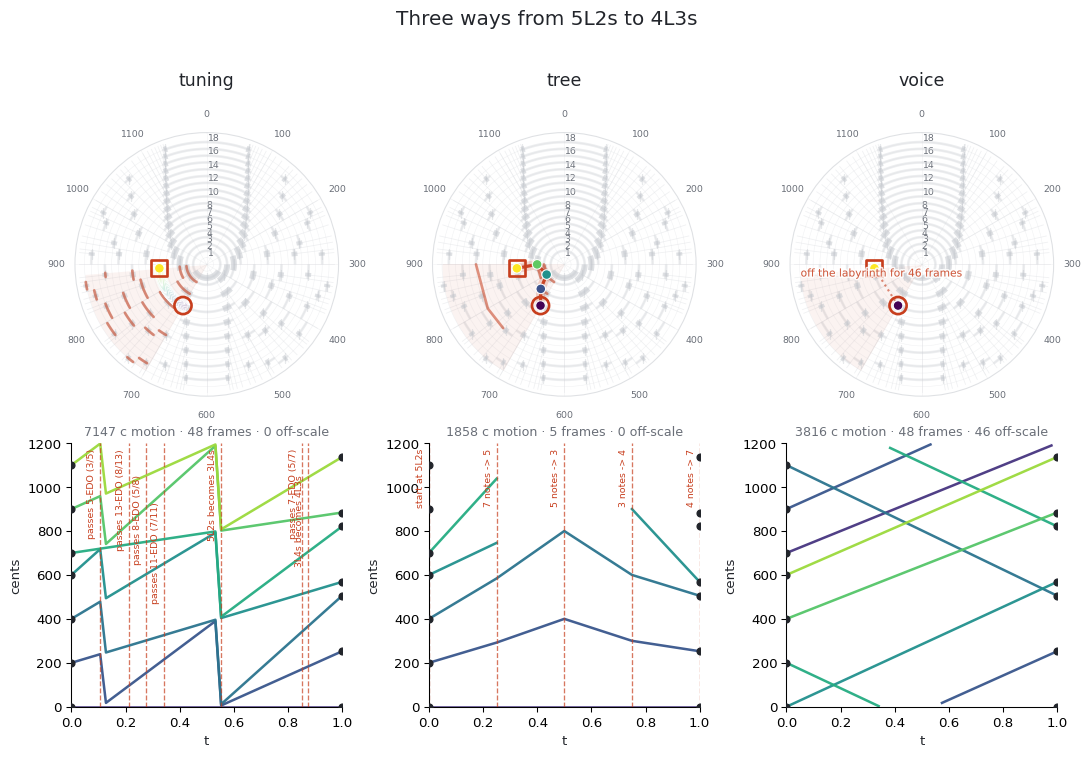

,strategy,frames,route,voice motion ¢,off-scale frames
0,tuning,48,5L2s → 3L4s → 4L3s,7147,0
1,tree,5,5L2s → 3L2s → 1L2s → 1L3s → 4L3s,1858,0
2,voice,48,5L2s → (off-scale) → 4L3s,3816,46


In [5]:
start = M.MOSScale.from_signature(5, 2, tuning=12)   # the familiar diatonic
end = M.MOSScale.from_signature(4, 3, tuning=19)     # 4L3s in 19-EDO

fig, morphs = M.plot_morph_comparison(start, end, steps=48, figsize=(11.5, 8.0))
plt.show()

pd.DataFrame([
    {
        "strategy": name,
        "frames": len(m),
        "route": " → ".join(m.signatures()),
        "voice motion ¢": round(m.voice_leading_distance()),
        "off-scale frames": sum(1 for s in m if not s.is_well_formed),
    }
    for name, m in morphs.items()
])

Three routes, then, not three descriptions of one. Voice motion comes to 7147 cents for
the tuning morph, 1858 for the tree morph and 3816 for the voice morph. Only the tuning
morph passes through equal temperaments on the way — five of them — and only it flips
its signature twice.

Its bill is the one the picture explains. Look at the bottom-left panel: the lines fall
off the bottom and reappear at the top. Sliding a generator drags notes over the period
boundary, and every crossing is motion that has to be paid for. Sample the same slide
more finely and the total climbs — 6095 cents at twelve frames, 7429 at 384 — so read
7147 as this route at this sampling. The ordering of the three is what is stable.

Why would a signature flip? Because a generator that keeps sliding eventually leaves
the stretch its scale occupies and enters the next one — over the tick, where large
and small trade places, or off the end, where a step size vanishes.

That flip is the thing to hear. Take the shortest journey that contains one: the
diatonic to its own inverse. The generator slides from 700 cents down to 685.7, which is
7-EDO, and then keeps going. At 7-EDO the two step sizes are equal, the scale is
momentarily an equal division, and on the far side `5L2s` has become `2L5s` — the same
seven notes, with large and small swapped.

The audio is eight seconds, all seven voices gliding at once.

The flip is also a warning about what follows. Sections 5 onward put a *recording* on
this map, and near a landmark two generators a few cents apart carry different
signatures — which is why the last section of this notebook refuses to report a fitted
generator as an identification.

In [6]:
flip = M.tuning_morph(start, start.inverse, steps=96)
print(flip.summary())

Audio(M.morph_audio(flip, fundamental=160.0, seconds=8.0, sample_rate=22050),
      rate=22050)

tuning morph:  5L2s (700.0 c) -> 2L5s (671.4 c)
  frames         96
  route          5L2s -> 2L5s
  voice motion   600.0 c total
  every frame is a well-formed scale
    t=0.179  passes 19-EDO (11/19)
    t=0.495  passes 7-EDO (4/7)
    t=0.505  5L2s becomes 2L5s: the large and small steps trade places
    t=0.874  passes 16-EDO (9/16)


## 5. From a biosignal

Everything above is music theory. Now a recording.

A peak finder hands back a few frequencies. Divide them by one another and there is a
set of ratios. Which well-formed scale do those ratios sit in?

Asking that turns the labyrinth into a *search space* with three coordinates —
generator, cardinality (the note count), period — and `fit_mos` searches it. Candidate
generators come from the signal itself: every observed ratio, and every ratio between
ratios, plus a background grid. For each candidate, only the cardinalities that are
genuinely well formed are tried.

The objective is amplitude-weighted mean cents error from each ratio to its nearest
degree, plus a penalty per surplus note.

There is a fourth, nuisance coordinate. A scale carries no built-in starting note, so
every candidate is free to rotate — to **transpose** — until its degrees line up with
the data.

That freedom is not a convenience. Stacking fifths gives the pentatonic's five notes,
but rooted on whichever note the stack began from; the same five rooted elsewhere is
the same scale in a different **mode**. Take the rotation away and a fit would be
testing the scale and its starting note at once, and failing whenever the signal had
picked a different one.

What comes back is a playable object, not a score. `MOSScale` hands over cents, ratios
and modes, so a recording can be retuned to the scale it implies, two conditions can be
compared by the scales they imply, or a piece can be written in the tuning a subject's
alpha rhythm suggests. The rest of the notebook is about how much weight that answer can
carry.

Start with a signal whose peaks really are a stack of fifths, buried in noise, so there
is a right answer to recover.

In [7]:
from biotuner.biotuner_object import compute_biotuner

rng = np.random.default_rng(7)
sf = 1000.0
t = np.arange(0, 30, 1 / sf)

base = 5.0
partials = [base, base * 1.5, base * 2.25, base * 3.375, base * 2.0]
amps = [1.0, 0.9, 0.75, 0.5, 0.65]
signal = sum(a * np.sin(2 * np.pi * f * t) for a, f in zip(amps, partials))
signal = signal + 0.25 * rng.standard_normal(t.size)

bt = compute_biotuner(sf, peaks_function="FOOOF", precision=0.1)
bt.peaks_extraction(signal, min_freq=2, max_freq=40, n_peaks=5)
print("peaks (Hz):", np.round(bt.peaks, 3))
print("ratios:    ", np.round(bt.peaks_ratios, 5))
print()

fit = bt.fit_mos(max_cardinality=16)
print(M.explain_fit(fit))

peaks (Hz): [ 5.    7.5   9.99 11.25 16.88]
ratios:     [1.125   1.12533 1.12613 1.332   1.5     1.50044 1.688   1.68969 1.998  ]



2L3s  (5 notes)   ssLsL
  generator       702.727 c  (ratio 1.500669, g = 0.585606)
  period         1200.000 c  (ratio 2.000000)
  steps          L = 291.820 c,  s = 205.453 c,  R = 1.4204
  valid range    1/2 .. 3/5   (600.0 .. 720.0 c)
  coherent over  4/7 .. 3/5   -> proper
  landmarks      equalized 3/5 = 5-EDO,  s->0 at 1/2 = 2-EDO,  L->0 at 2/3 = 3-EDO
  inverse        3L2s
  embedded in    7 notes (equal at 4/7)
  fit            error 0.577 c (weighted mean), max 1.149 c, rms 0.681 c
  chance         60.000 c for 5 degrees;  improvement 103.92x;  evidence 4.54 SE below chance
  coverage       100.0% of weight within tolerance;  7 targets, 0 unused degrees;  score 0.577
  folded         2 ratio(s) merged into a pitch class already present (an octave is not a second target)


### Reading that block

`explain_fit` prints three numbers and one flag. The numbers only mean anything
together.

**error** on its own means nothing. Nearest-degree matching guarantees that a bigger
scale sits at least as close to any data, so the raw error is a race to the largest ring
allowed.

**chance** is the yardstick — what a *random* set of ratios would score against a scale
of this size. Uniformly scattered points land on average a quarter of a step from the
nearest of `N` equally spaced degrees, so chance is `period / (4N)`: 60 cents for a
five-note scale, 25 for a twelve-note one. Beating chance is the minimum, not the
finding.

**UNDERDETERMINED** fires when the scale has more degrees than the data had targets
(`MOSFit.is_underdetermined`). A scale with spare degrees can be rotated until
everything lands on something, so its error stops being a measurement. Such a fit is
flagged rather than dropped: five peaks cannot produce twelve targets, but the structure
may still be right. It does not fire above — seven targets, five degrees.

**evidence** is the one to rank on: `sqrt(3n) · (1 − error / chance)`, the number of
standard errors the weighted mean falls below chance. It counts how much data the margin
was measured over, so it self-limits at `sqrt(3n)`. Two exact targets can never exceed
2.45 however perfect they are, while seven exact targets reach 4.58.

The lower panel below draws the chance band directly. Its edge is the *average* distance
a random ratio falls from the nearest of five degrees — an expected value, not a
threshold. So the question is not whether the residuals are inside the grey but whether
they *fill* it. Residuals scattered through the band are what chance looks like. These
sit on the zero line.

The top panel has no vertical axis; the dots are parked at mid-height so they can be
read against the degrees.

For that reading to be honest the degrees have to be drawn where the fit *put* them.
`MOSScale` roots its degrees on wherever the generator chain happened to start, which
is arbitrary, and the fit then transposes the whole scale onto the data — 496.3 cents
here. The code below applies that shift before drawing, so every dot should be sitting
on a line.

Count them and there are five, from nine ratios, for two different reasons. Folding
merges what sits within a cent — 1.125 with 1.12533, 1.5 with 1.50044 — and that is what
takes nine ratios to seven targets. The other two coincidences are only visual: 1.12613
is a separate target 1.7 cents above 1.125, as 1.68969 is 1.7 cents above 1.688, and 1.7
cents is narrower than a marker.

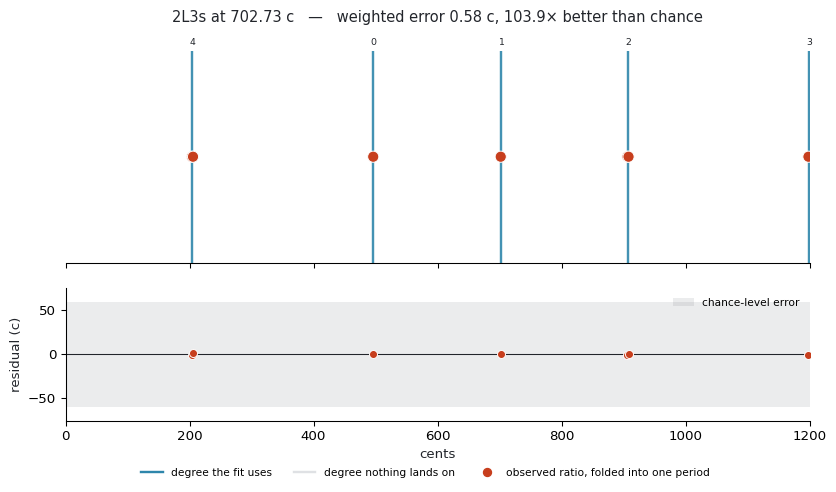

In [8]:
fig, axes = M.plot_mos_fit(fit, bt.peaks_ratios, figsize=(10.0, 5.0))
top, bot = axes[0], axes[-1]
top.set_title(top.get_title(), fontsize=11, pad=22)   # clear the degree numbers
bot.set_ylim(-75, 75)
fig.legend(
    handles=[
        Line2D([], [], color="#2E86AB", lw=1.8, label="degree the fit uses"),
        Line2D([], [], color="#dfe1e4", lw=1.8, label="degree nothing lands on"),
        Line2D([], [], color="#C73E1D", marker="o", ls="none", ms=6,
               label="observed ratio, folded into one period"),
    ],
    fontsize=8, frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.03),
)
plt.show()


## 6. Two directions, two questions

`fit_mos` treats the generator as **latent**. It solves for the value that best
organises the peaks, whether or not the signal ever states that interval.

`forward_scales` runs the other way. It takes an interval the signal *does* state — a
ratio, or the quotient of two peaks — declares it the generator, stacks it, and reads
off the scale that falls out. Nothing is optimised; the generator equals the observed
interval bit for bit.

They answer different questions and are allowed to disagree.

A word of warning about the names. `fit_mos` is the *inverse* problem, solved backwards
from the data; `forward_scales` is the *forward* one. That `inverse` has nothing to do
with `5L2s`'s inverse `2L5s` from sections 2 and 4. Same word, unrelated meanings, and
both appear below.

Ask the inverse when you want the scale and do not care where the generator came from.
Ask the forward when the *provenance* of the generator is the claim: "this signal's
alpha-to-beta ratio, stacked, gives a pentatonic" is only honest if the interval you
stacked is one the signal produced.

Both score against the same targets with the same objective, so their `error_cents`,
`coverage` and `evidence` can be read against each other.

`plot_forward_vs_inverse` puts them on one labyrinth. Each forward reading is a dot at
its (generator, cardinality); the inverse fit is a star on its own ray.

A dot's size is how many observed intervals proposed that generator, and its colour is
the error, dark being better. So a large dark dot is a reading the signal argued for
more than once and which also fits.

Only half the disc is drawn, 600 to 1200 cents. A generator and its complement build
the same scale, so every reading folds into that half.

Two experiments below.

On this signal the two directions **agree**, which is the interesting outcome rather
than the usual one: the latent generator turned out to be audible after all.

Then the generator is removed from the signal. Take a stack of fifths,
`[1, 9/8, 81/64, 3/2, 27/16]`, and delete the `3/2`. The inverse still returns `2L3s` at
701.955 cents with zero error, because 27/16 over 9/8 is a fifth and the search has no
reason to care about the difference.

Read only the listed ratios as generators (`include_intervals=False`, so no quotients)
and the forward direction cannot reach it at all.

In [9]:
forward = M.forward_scales(bt.peaks_ratios, min_cardinality=4, max_cardinality=12)
inverse = M.best_mos(bt.peaks_ratios, min_cardinality=4, max_cardinality=12)

print(f"inverse (latent generator): {inverse.signature} @ "
      f"{inverse.scale.generator_cents:.2f} ¢, error {inverse.error_cents:.2f} ¢")
print(f"forward (observed interval): {forward[0].signature} @ "
      f"{forward[0].scale.generator_cents:.2f} ¢, error {forward[0].error_cents:.2f} ¢, "
      f"proposed by {forward[0].n_sources} observed intervals")
print()

pd.DataFrame([
    {
        "signature": f.signature,
        "notes": f.scale.cardinality,
        "generator ¢": round(f.scale.generator_cents, 2),
        "error ¢": round(f.error_cents, 2),
        "coverage": round(f.coverage, 2),
        "evidence": round(f.evidence, 2),
        "intervals proposing it": f.n_sources,
    }
    for f in forward[:6]
])

inverse (latent generator): 2L3s @ 702.73 ¢, error 0.58 ¢
forward (observed interval): 2L3s @ 702.47 ¢, error 0.60 ¢, proposed by 9 observed intervals



,signature,notes,generator ¢,error ¢,coverage,evidence,intervals proposing it
0,2L3s,5,702.47,0.60,1.0,4.54,9
1,5L2s,7,702.47,0.60,1.0,4.52,9
2,2L3s,5,703.17,0.68,1.0,4.53,5
3,5L2s,7,703.17,0.68,1.0,4.51,5
4,2L3s,5,701.44,1.40,1.0,4.48,2
5,5L2s,7,701.44,1.40,1.0,4.43,2


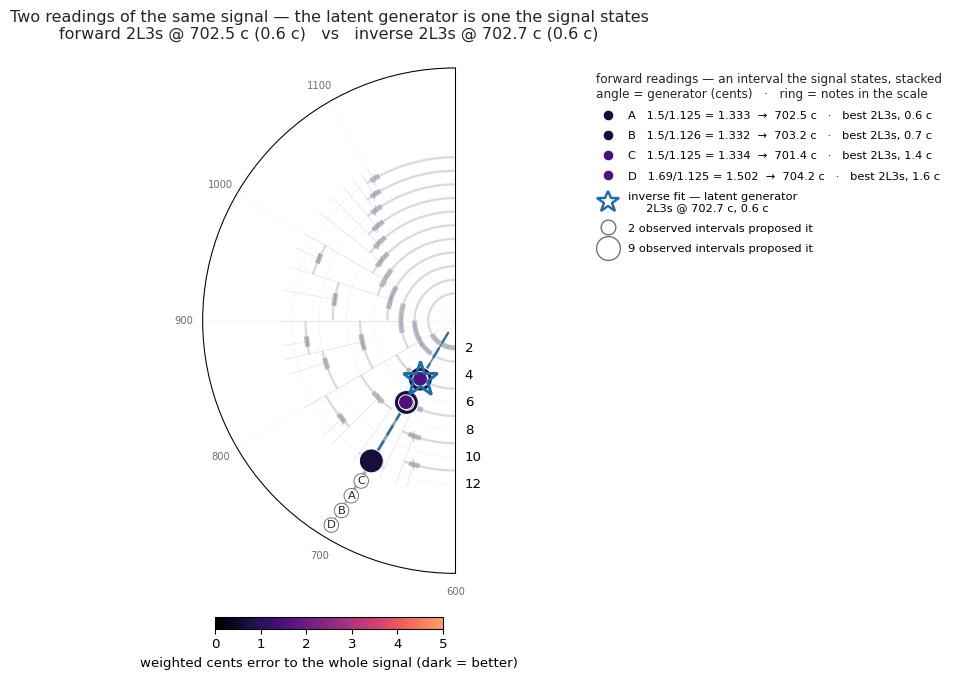

In [10]:
fig, ax = M.plot_forward_vs_inverse(forward, inverse, top_n=10)
plt.show()

In [11]:
missing = [1, 9 / 8, 81 / 64, 27 / 16]          # a stack of fifths, minus the fifth

inv = M.best_mos(missing, max_cardinality=12)
print(f"inverse                       {inv.signature} @ "
      f"{inv.scale.generator_cents:.4f} ¢, error {inv.error_cents:.6f} ¢")

for label, kwargs in [("forward, ratios only   ", dict(include_intervals=False)),
                      ("forward, ratios + pairs", dict())]:
    best = M.forward_scales(missing, min_cardinality=4, max_cardinality=12, **kwargs)[0]
    print(f"{label}       {best.signature} @ "
          f"{best.scale.generator_cents:.4f} ¢, error {best.error_cents:.2f} ¢")

inverse                       2L3s @ 701.9550 ¢, error 0.000000 ¢
forward, ratios only          1L3s @ 996.0900 ¢, error 22.56 ¢
forward, ratios + pairs       2L3s @ 701.9550 ¢, error 0.00 ¢


## 7. Which derivation?

Section 5 fitted the peak ratios. But peak ratios are one reading of a recording among
several.

`compute_biotuner` turns one recording into ratios eight different ways — peak ratios,
consonance-filtered ratios, extended peaks, dissonance-curve minima, harmonic-entropy
minima, an Euler-Fokker genus, a common-harmonic tuning, a harmonic fit — and they do
not agree. Each is a first-class input to the fit.

`compare_mos_sources` runs the whole set and ranks it, so the question stops being
"which scale is this signal in?" and becomes "which way of asking produces a well-formed
answer at all?".

In [12]:
bt.peaks_extension(method="harmonic_fit", harm_function="mult", cons_limit=0.1)

comparison = bt.compare_mos_sources(max_cardinality=16)
table = comparison[[
    "source", "n_ratios", "n_targets", "signature", "cardinality",
    "error_cents", "improvement", "evidence", "coverage", "underdetermined",
]].round(3)
for r in comparison.itertuples():
    if r.reason:
        print(textwrap.fill(f"{r.source} raised and kept its row: {r.reason.split('. ')[0]}.", 96))

table

harm_tuning raised and kept its row: ValueError: harmonic_tuning() needs harmonic positions and
this object has none: self.all_harmonics is only measured by
peaks_extraction(peaks_function='harmonic_recurrence'), and peaks_function is 'FOOOF'.


,source,n_ratios,n_targets,signature,cardinality,error_cents,improvement,evidence,coverage,underdetermined
0,peaks_ratios,9.0,7.0,2L3s,5.0,0.577,1.039200e+02,4.538,1.000,False
1,extended_ratios,18.0,17.0,12L1s,13.0,9.949,2.320000e+00,4.063,0.722,False
2,diss_curve,8.0,8.0,7L3s,10.0,5.192,5.779000e+00,4.051,0.875,True
3,euler_fokker,9.0,8.0,4L7s,11.0,6.932,3.934000e+00,3.654,0.889,True
4,HE,5.0,5.0,1L8s,9.0,4.707,7.082000e+00,3.326,0.800,True
5,cons_ratios,2.0,2.0,3L1s,4.0,0.000,5.158593e+07,2.449,1.000,True
6,harm_fit_tuning,37.0,37.0,3L13s,16.0,16.285,1.151000e+00,1.385,0.541,False
7,harm_tuning,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,None


Start with the `error_cents` column, because it is a trap. The smallest error in the
table belongs to `cons_ratios`, at a few millionths of a cent — and it ranks sixth. It
derived two ratios, and a four-note scale has enough spare degrees to be rotated until
both land exactly. That number measures the scale's slack, not the signal.

`improvement` does not rescue the ranking either: dividing by chance puts the same
two-point fit on top by seven orders of magnitude.

`evidence` is the column that behaves, and it is what the rows are sorted by.

A source that raises keeps its row too, with the exception text in `reason`. A shorter
table is not a report of a broken source.

Note how many rows carry `underdetermined`. That is the honest reading of five peaks,
not a bug, and the last section of this notebook is about what to do with it.

## 8. How well formed is it?

`fit_mos` answers "which scale", and `evidence` says the answer beats noise. But how
would you know if the whole exercise were nonsense?

Noise is a weak alternative. Any `N`-note scale with somewhere to slide beats noise. The
alternative that matters is **an equally spaced scale of the same size**, which has all
the same coverage and none of the structure. If the generator is contributing nothing,
the equal division will fit the data as closely without it.

`metrics.mos_ness` is that comparison, run at one fixed cardinality across a ladder of
increasing freedom:

| family | shape | free parameters |
| --- | --- | --- |
| `edo` | `N` equal steps | 1 (transposition) |
| `mos` | one generator, two step sizes | 2 |
| `ternary` | three step sizes | 3 |

Each rung down the table buys one more parameter. The statistic asks what the parameter
buys back.

`mos_ness` is the share of the equal division's error that the generator removes, after
both errors are corrected for the parameters that produced them. It scores 1.0 on a real
moment of symmetry and 0 on an equal division, where the generator has nothing left to
remove. Being a ratio between two fits to the same data at the same cardinality, it
survives what the fitted generator does not.

The third rung is worth watching too. `two_step_sufficiency` asks how much of what a
*third* step size explains was already covered by two. A value of 1.0 says the third
step is redundant and the signal is well formed rather than merely non-uniform. On the
meantone scale below, the ternary fit collapses two of its three step sizes onto each
other, which is the third step size visibly declining to exist.

Two of the three rows below are not measurements. The first two are constructed
identities — seven degrees for seven targets — and `mos_ness` says as much in its own
closing note. They are there to show the statistic reading 1.0 and 0.0 at the two ends
of the ladder, not to be evidence about anything. Only the third row is a measurement.

In [13]:
edo7 = [2 ** (k / 7) for k in range(7)]

for label, ratios in [
    ("a real MOS (31-EDO meantone)", M.MOSScale.from_signature(5, 2, tuning=31).ratios),
    ("an equal division (7-EDO)", edo7),
    ("the signal's peak ratios", bt.peaks_ratios),
]:
    r = M.mos_ness(ratios, ternary=True)
    print(f"----- {label}")
    print(r.summary())
    print()

----- a real MOS (31-EDO meantone)
MOS-ness 1.000   at 7 notes   (cardinality chosen by: edo-evidence)
  targets        7 pitch classes, 0 merged, period 1200.000 c
  equal div.     7-EDO                  error   18.960 c   (1 parameter)
  well formed    5L2s @ 696.774 c       error    0.000 c   (2 parameters)
  three steps    2L2M3s LMsLsMs         error    0.000 c   (3 parameters)
  step sizes     193.5, 116.1, 193.5 c  (two of them equal)
  two-step suff. 1.000                  ternary-ness 1.000
  note           cardinality 7 is not below the 7 targets: the fit has a degree
                 per observation and is not evidence



----- an equal division (7-EDO)
MOS-ness 0.000   at 7 notes   (cardinality chosen by: edo-evidence)
  targets        7 pitch classes, 0 merged, period 1200.000 c
  equal div.     7-EDO                  error    0.000 c   (1 parameter)
  well formed    6L1s @ 1028.571 c      error    0.000 c   (2 parameters)
  three steps    2L2M3s LsMLsMs         error    0.000 c   (3 parameters)
  step sizes     171.4, 171.4, 171.4 c  (two of them equal)
  two-step suff. 1.000                  ternary-ness 0.000
  note           cardinality 7 is not below the 7 targets: the fit has a degree
                 per observation and is not evidence



----- the signal's peak ratios
MOS-ness 0.960   at 5 notes   (cardinality chosen by: edo-evidence)
  targets        7 pitch classes, 2 merged, period 1200.000 c
  equal div.     5-EDO                  error   17.354 c   (1 parameter)
  well formed    2L3s @ 702.727 c       error    0.577 c   (2 parameters)
  three steps    1L1M3s LssMs           error    0.385 c   (3 parameters)
  step sizes     292.4, 290.7, 205.6 c
  two-step suff. 0.993                  ternary-ness 0.967



## Reading a fit honestly

These are lessons from applying the module to twenty nights of PhysioNet sleep EEG and
ten subjects of motor-imagery EEG. They cost real time to learn and they are cheap to
apply.

**Feed it the peaks, not `bt.peaks_ratios`.**

The latter is every pairwise quotient, so `n` peaks become up to `n(n−1)/2` targets.
Those are not `n(n−1)/2` independent observations: they are all derived from the same
`n` numbers. The fitter cannot know that, and will happily answer with a scale carrying
more degrees than the recording had peaks. Pass `bt.peaks` with `bt.amps` as weights
when the question is about the recording.

In the table below the ratios post the *higher* evidence — 4.54 against 3.85 — and that
is the inflation, not a reason to prefer them. Evidence grows as `sqrt(3n)`, so counting
seven targets where five measurements were made inflates the score by `sqrt(7/5)`, about
eighteen per cent, for nothing.

**Cap the cardinality below the target count.**

Without a cap, seventy per cent of fits in those datasets had more notes than targets,
and a six-cent error meant nothing. The harmonic-entropy source below is the pattern in
miniature: nine notes for five targets at 4.7 cents looks excellent and is not a
measurement. Capped at four notes, the real error appears.

The cap is a guard, not an improvement. Where the unconstrained fit already used no more
notes than there were targets — the first row of the table — forcing it smaller only
discards a degree the data had paid for, and the evidence falls.

In [14]:
print(f"{len(bt.peaks)} peaks -> {len(bt.peaks_ratios)} pairwise ratios "
      f"-> {M.fit_mos(bt.peaks_ratios, max_cardinality=16)[0].n_targets} pitch classes")
print()

rows = []
for label, ratios, weights in [
    ("peaks + amps", list(bt.peaks), list(bt.amps)),
    ("peaks_ratios", list(bt.peaks_ratios), None),
]:
    for cap in (16, 4):
        f = M.fit_mos(ratios, weights=weights, max_cardinality=cap)[0]
        rows.append({
            "input": label, "max_cardinality": cap,
            "targets": f.n_targets, "notes": f.scale.cardinality,
            "signature": f.signature,
            "generator ¢": round(f.scale.generator_cents, 1),
            "error ¢": round(f.error_cents, 2),
            "evidence": round(f.evidence, 2),
            "underdetermined": f.is_underdetermined,
        })

he = bt.get_tuning("HE")
for cap in (16, 4):
    f = M.fit_mos(he, max_cardinality=cap)[0]
    rows.append({
        "input": "harmonic entropy", "max_cardinality": cap,
        "targets": f.n_targets, "notes": f.scale.cardinality,
        "signature": f.signature,
        "generator ¢": round(f.scale.generator_cents, 1),
        "error ¢": round(f.error_cents, 2),
        "evidence": round(f.evidence, 2),
        "underdetermined": f.is_underdetermined,
    })
pd.DataFrame(rows)

5 peaks -> 9 pairwise ratios -> 7 pitch classes



,input,max_cardinality,targets,notes,signature,generator ¢,error ¢,evidence,underdetermined
0,peaks + amps,16,5,5,2L3s,702.2,0.40,3.85,False
1,peaks + amps,4,5,4,1L3s,951.8,15.73,3.06,False
2,peaks_ratios,16,7,5,2L3s,702.7,0.58,4.54,False
3,peaks_ratios,4,7,4,1L3s,953.4,32.57,2.59,False
4,harmonic entropy,16,5,9,1L8s,1096.4,4.71,3.33,True
5,harmonic entropy,4,5,4,1L3s,965.7,42.16,1.70,False


**The generator is not reproducible from a handful of noisy peaks.**

Across reasonable peak-extraction settings on the EEG datasets it moved by 150 to 350
cents, and sleep-stage orderings built on it did not replicate across extraction
methods. The same instability is visible on this deliberately clean synthetic signal in
under a second: the signature holds while the generator wanders by a hundred cents.
Report a fitted generator as *what was compared*, not as an identification.

The sweep below applies the two rules just given — peaks and amplitudes rather than
pairwise ratios, and a ceiling one below the peak count but never under four, which is
four notes in every row here. It therefore asks a harder question than section 5 did,
and *none* of its rows returns the `2L3s` at 702.7 c that headlines this notebook.

That is the demonstration, not a contradiction of it. The same generator that survives a
sixteen-note ceiling on pairwise ratios does not survive a four-note ceiling on five
peaks. The signature is what holds.

In [15]:
sweep = []
for peaks_function, n_peaks, precision in [
    ("FOOOF", 5, 0.1), ("EMD", 5, 0.5), ("harmonic_recurrence", 5, 0.5),
    ("fixed", 7, 1.0), ("adapt", 5, 0.5),
]:
    b = compute_biotuner(sf, peaks_function=peaks_function, precision=precision)
    b.peaks_extraction(signal, min_freq=2, max_freq=40, n_peaks=n_peaks)
    cap = max(4, len(b.peaks) - 1)          # the rule from the section above
    f = M.fit_mos(b.peaks, weights=b.amps, max_cardinality=cap)[0]
    sweep.append({
        "peaks_function": peaks_function,
        "peaks (Hz)": np.round(b.peaks, 2).tolist(),
        "cap": cap,
        "signature": f.signature,
        "generator ¢": round(f.scale.generator_cents, 1),
        "error ¢": round(f.error_cents, 2),
    })
pd.DataFrame(sweep)

Adaptive frequency bands:  [[np.float64(1.5), np.float64(2.3)], [np.float64(3.0), np.float64(4.6)], [np.float64(6.1), np.float64(9.3)], [np.float64(12.1), np.float64(18.5)], [np.float64(24.3), np.float64(37.1)]]


,peaks_function,peaks (Hz),cap,signature,generator ¢,error ¢
0,FOOOF,"[5.0, 7.5, 9.99, 11.25, 16.88]",4,1L3s,951.8,15.73
1,EMD,"[2.5, 5.0, 7.5, 11.5]",4,1L3s,953.3,1.57
2,harmonic_recurrence,"[5.0, 7.5, 10.0, 22.5, 17.0]",4,1L3s,966.0,11.84
3,fixed,"[5.0, 11.0, 17.0, 36.0]",4,1L3s,1044.2,16.51
4,adapt,"[3.5, 7.5, 17.0, 36.0]",4,1L3s,1055.0,17.91


**`mos_ness` needs a null matched to your own target count — and, for spectral peaks, to
your own minimum peak spacing.**

The band quoted in the docstring (mean 0.09) is for *twenty* targets, and it is much too
low for the seven or eight a peak finder returns.

Worse, how the surrogate is built decides the answer. A peak finder cannot return two
peaks on top of each other, so a real set carries a minimum separation that a
log-uniform draw does not — and the equal division in the denominator of `mos_ness` is
precisely an evenness statistic.

On one EEG dataset, the same epochs at the same cardinality gave Cliff's delta −0.12
against a log-uniform surrogate and +0.04 against a spacing-matched one. The null decided
the sign of the answer.

Twelve draws of each kind is far too few to pin either band down. The two samples
overlap almost entirely, and both reach above the 0.33 the docstring quotes as a
maximum. What they are enough to show is that the surrogate rule moves the centre of the
band, and that neither band is the one quoted. Generate yours from your own data, the
same way, before calling a `mos_ness` high or low.

On the clean synthetic signal below the measured 0.96 clears both nulls, so the choice
makes no difference here. On the EEG it decided the sign.

In [16]:
def log_uniform(n, lo, hi, rng):
    return np.sort(np.exp(rng.uniform(np.log(lo), np.log(hi), n)))


def spacing_matched(n, lo, hi, min_sep_octaves, rng, tries=500):
    # Log-uniform, but rejecting draws a peak finder could never have produced.
    for _ in range(tries):
        x = log_uniform(n, lo, hi, rng)
        if np.min(np.diff(np.log2(x))) >= min_sep_octaves:
            return x
    return x  # unreachable here; in real use, check rather than fall through


min_sep = float(np.min(np.diff(np.log2(np.sort(bt.peaks)))))
n_targets = M.mos_ness(bt.peaks_ratios, ternary=False).n_targets

null = {}
for label, draw in [
    ("log-uniform", lambda r: log_uniform(n_targets, 2.0, 40.0, r)),
    ("spacing-matched", lambda r: spacing_matched(n_targets, 2.0, 40.0, min_sep, r)),
]:
    r = np.random.default_rng(11)
    null[label] = np.array([M.mos_ness(draw(r), ternary=False).mos_ness
                            for _ in range(12)])

print(f"minimum observed peak spacing: {min_sep:.3f} octaves;  {n_targets} targets")
print(f"measured signal:  mos_ness "
      f"{M.mos_ness(bt.peaks_ratios, ternary=False).mos_ness:.3f}")
pd.DataFrame([
    {"surrogate": k, "median": round(float(np.median(v)), 3),
     "90th pct": round(float(np.quantile(v, 0.9)), 3),
     "max": round(float(v.max()), 3)}
    for k, v in null.items()
])

minimum observed peak spacing: 0.171 octaves;  7 targets


measured signal:  mos_ness 0.960


,surrogate,median,90th pct,max
0,log-uniform,0.147,0.271,0.445
1,spacing-matched,0.219,0.386,0.749


## Where next

**[mos.ipynb](mos.ipynb)** — the full tour, in fourteen sections. Everything here at more
length, plus the parts this notebook skipped: the modal algebra and the ℤ² height–width
lattice, named temperaments computed from their commas, where the labyrinth approximates
just intonation, trajectories through the labyrinth over time, Fourier Scratching, and
Dynamic Tonality timbre matching.

**[explorers.ipynb](explorers.ipynb)** — the ten interactive explorers. Drag the generator
and watch the family, the wheel, the summary and the fit against your own signal
recompute live; step through ranked fits; put a slider on every Fourier coefficient; move
between scales with the morph explorer. They need `pip install biotuner[interactive]`,
and widgets do not render in a built book, so they have to be run.

**[mos_architecture.md](../../mos_architecture.md)** — the design document: what each
module does, which claims were tested, and the two places the paper needed sharpening.